In [1]:
ls

CR_advection.cpp             main.cpp
CR_advection.hpp             main.o
CR_advection.o               ndis_B_1GeV_vbreeze1000.bin
Makefile                     ndis_C_1GeV_vbreeze1000.bin
a.out*                       vR.bin
advection.ipynb              vZ.bin


In [3]:
from astropy import constants as const
from astropy import units as u
import numpy as np
import matplotlib.pyplot as plt

def grid_R(NR, dR):
    R = np.zeros(NR)
    l = 10 / dR
    for i in range(NR):
        if i * dR < 10:
            R[i] = i * dR
        else:
            R[i] = 10** ((i + l ) / 2 / l)
    return R
def grid_Z(NZ, dZ):
    Z = np.zeros(NZ)
    l = 1 / dZ
    for i in range(NZ):
        if i * dZ < 1:
            Z[i] = i * dZ
        else:
            Z[i] = 10** ((i - l) / l)
    return Z
NR = 300
NZ = 150
R = grid_R(NR + 1,0.1)
Z = grid_Z(NZ + 1,0.02)
print(R[-1], Z[-1])

100.0 100.0


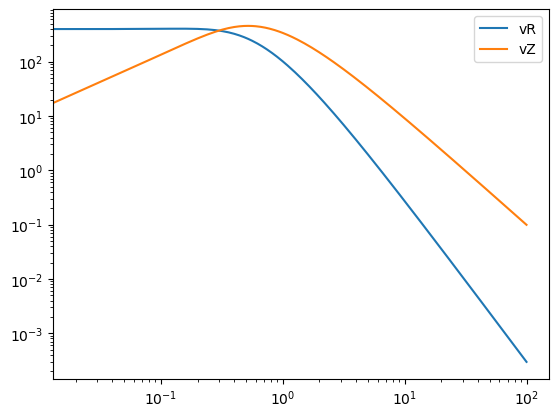

In [35]:
vR = np.fromfile("vR.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)
vZ = np.fromfile("vZ.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)

# plt.plot(R, vR[2:-1,10],label = "vR")
# plt.plot(R, vZ[2:-1,10],label = "vZ")

plt.plot(Z, vR[5,2:-1],label = "vR")
plt.plot(Z, vZ[5,2:-1],label = "vZ")

plt.xscale("log")
plt.yscale("log")
# plt.ylim(1e3,1e6)
plt.legend()

In [51]:
v = (vR[2:-1,2:-1]**2 + vZ[2:-1,2:-1]**2)**0.5
r = (R[:,None]**2 + Z[None,:]**2)**0.5 + 1e-10
temp = 1000 * np.exp(-1 / r) / r**2
a = v / temp
a[0,0] = 1.0
a

/var/folders/kb/y54l9s817n95k14028l22_h40000gp/T/ipykernel_37148/331084614.py:4: RuntimeWarning: invalid value encountered in divide
  a = v / temp


array([[1.        , 1.02376565, 1.00551362, ..., 0.99999967, 0.99999969,
        0.9999997 ],
       [1.00070015, 1.0006675 , 1.00058362, ..., 0.99999967, 0.99999969,
        0.9999997 ],
       [1.00009999, 1.00009826, 1.00009329, ..., 0.99999967, 0.99999969,
        0.9999997 ],
       ...,
       [0.99999969, 0.99999969, 0.99999969, ..., 0.99999978, 0.99999978,
        0.99999979],
       [0.9999997 , 0.9999997 , 0.9999997 , ..., 0.99999978, 0.99999978,
        0.99999979],
       [0.9999997 , 0.9999997 , 0.9999997 , ..., 0.99999978, 0.99999978,
        0.99999979]], shape=(301, 151))

In [52]:
np.max(a)

np.float64(1.0237656480736095)

In [67]:
vR[2:6,2:6]

array([[  0.        ,   0.        ,   0.        ,   0.        ],
       [  4.5431717 ,   5.20154097,   7.43435636,  11.90843714],
       [168.46551921, 170.1393687 , 175.03569858, 182.78650084],
       [396.38210727, 396.67182628, 397.49626144, 398.72674923]])

In [68]:
vZ[2:6,2:6]

array([[0.00000000e+00, 4.93647078e-16, 8.72782343e-06, 1.60858931e-02],
       [0.00000000e+00, 1.04030819e+00, 2.97374254e+00, 7.14506229e+00],
       [0.00000000e+00, 1.70139369e+01, 3.50071397e+01, 5.48359503e+01],
       [0.00000000e+00, 2.64447884e+01, 5.29995015e+01, 7.97453498e+01]])

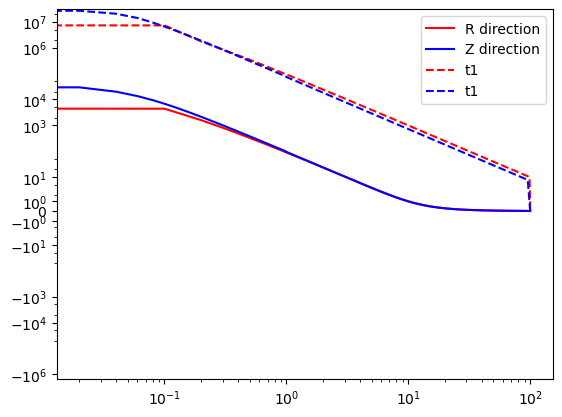

In [103]:
ndis_C_t0 = np.fromfile("ndis_C_1GeV_t0.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)
ndis_C_t1 = np.fromfile("ndis_C_1GeV_t1.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)
ndis_C_ds = np.fromfile("ndis_C_1GeV_disksrc.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)

plt.plot(R, ndis_C_t0[2:-1,2],label = "R direction", c = "red")
plt.plot(Z, ndis_C_t0[2,2:-1],label = "Z direction", c = "blue")

plt.plot(R, ndis_C_t1[2:-1,2],label = "t1",linestyle="--", c = "red")
plt.plot(Z, ndis_C_t1[2,2:-1],label = "t1",linestyle="--", c = "blue")

plt.xscale("log")
plt.yscale("asinh")
# plt.ylim(1e3,1e6)
plt.legend()

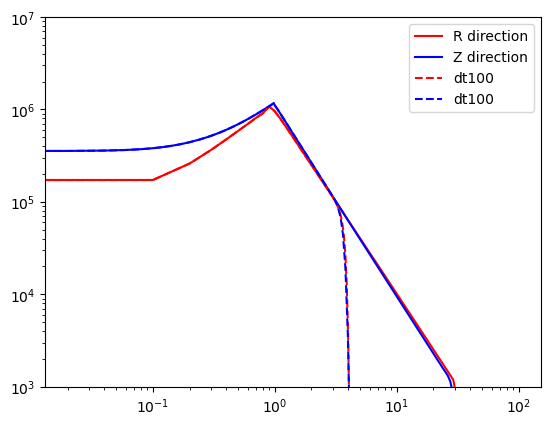

In [149]:
ndis_C_ds = np.fromfile("ndis_C_1GeV_disksrc.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)
ndis_C_ds_dt100 = np.fromfile("ndis_C_1GeV_disksrc_dt100.bin",dtype = np.float64).reshape(NR + 4, NZ + 4)

plt.plot(R, ndis_C_ds[2:-1,5],label = "R direction", c = "red")
plt.plot(Z, ndis_C_ds[5,2:-1],label = "Z direction", c = "blue")

plt.plot(R, ndis_C_ds_dt100[2:-1,5],label = "dt100", c = "red", linestyle="--")
plt.plot(Z, ndis_C_ds_dt100[5,2:-1],label = "dt100", c = "blue", linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.ylim(1e3,1e7)
plt.legend()

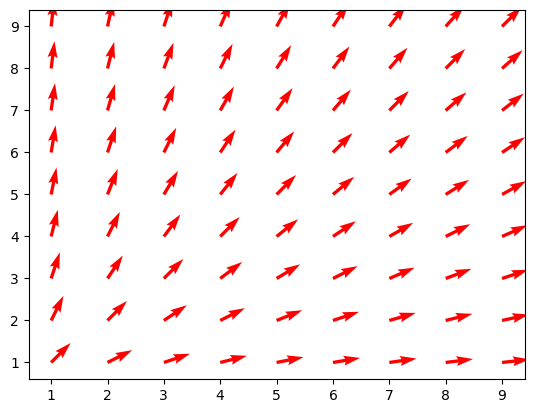

In [139]:
import matplotlib.pyplot as plt
import numpy as np

# 1. 准备网格与方向数据
x = np.arange(1, 10, 1)
y = np.arange(1, 10, 1)
X, Y = np.meshgrid(x, y)
r = (X**2 + Y**2)**0.5
U = X / r
V = Y / r

# 2. 绘制箭头图
plt.figure()
plt.quiver(X, Y, U, V, color='r')

# 3. 显示图形
plt.show()


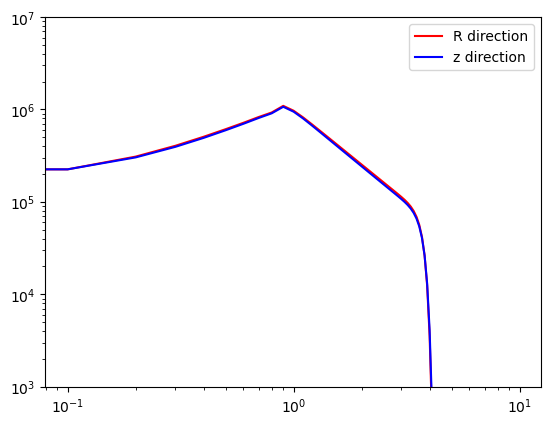

In [154]:
NX = 100
x = np.linspace(0, 10, NX, endpoint=False)

ndis_C = np.fromfile("ndis_C_linear.bin",dtype = np.float64).reshape(NX + 4, NX + 4)

plt.plot(x, ndis_C[2:-2,0],label = "R direction", c = "red")
plt.plot(x, ndis_C[0,2:-2],label = "z direction", c = "blue")

# plt.plot(R, ndis_C_ds_dt100[2:-1,5],label = "dt100", c = "red", linestyle="--")
# plt.plot(Z, ndis_C_ds_dt100[5,2:-1],label = "dt100", c = "blue", linestyle="--")

plt.xscale("log")
plt.yscale("log")
plt.ylim(1e3,1e7)
plt.legend()

In [194]:
ndis_C = np.fromfile("ndis_C_linear_t_delta_inj.bin",dtype = np.float64).reshape(100,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0, 100, NX, endpoint = False)
y = np.linspace(0, 100, NX, endpoint = False)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in[0].T,shading="auto", vmin = 0.01, vmax = 10 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=50,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [202]:
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
N_tot

array([45000.27172927, 45250.84407456, 45467.67998404, 45659.4547566 ,
       45831.49857514, 45987.4351248 , 46129.91407376, 46260.94327973,
       46382.09537559, 46494.62968247, 46599.55931946, 46697.71817892,
       46789.81270368, 46876.44878832, 46958.14201627, 47035.33562303,
       47108.42185882, 47177.74529285, 47243.60803239, 47306.27821465,
       47365.99710952, 47422.98061819, 47477.42129636, 47529.49405771,
       47579.35848278, 47627.15777826, 47673.02291507, 47717.07419551,
       47759.42120539, 47800.16459789, 47839.39705075, 47877.20432273,
       47913.66464082, 47948.85139964, 47982.83248236, 48015.67010847,
       48047.42296911, 48078.145496  , 48107.88838371, 48136.69867831,
       48164.62094958, 48191.69677078, 48217.96448522, 48243.46092316,
       48268.22030979, 48292.27478479, 48315.65456388, 48338.38832335,
       48360.50313852, 48382.02413431, 48402.97562119, 48423.38024533,
       48443.2595135 , 48462.63380811, 48481.52246931, 48499.9439497 ,
      

In [193]:
import matplotlib.pyplot as plt
import numpy as np

import matplotlib.animation as animation
from IPython.display import HTML
import random

ndis_C = np.fromfile("ndis_C_linear_t.bin",dtype = np.float64).reshape(100,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0, 100, NX, endpoint = False)
y = np.linspace(0, 100, NX, endpoint = False)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_log[0].T,shading="auto", vmin = -1, vmax = 5)

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_log[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=100,
    interval=50,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())


In [205]:
ndis_C = np.fromfile("ndis_C_linear_t_delta_inj_dt10.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0, 100, NX, endpoint = False)
y = np.linspace(0, 100, NX, endpoint = False)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=20,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

In [206]:
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
N_tot

array([4500.00271729, 4502.69638816, 4505.34408308, 4507.9475552 ,
       4510.50846068, 4513.02836478, 4515.50874736, 4517.95100787,
       4520.35647001, 4522.72638604, 4525.06194074, 4527.36425531,
       4529.6343909 , 4531.87335213, 4534.08209039, 4536.26150701,
       4538.41245632, 4540.53574857, 4542.63215279, 4544.70239943,
       4546.74718291, 4548.7671641 , 4550.76297259, 4552.73520885,
       4554.68444624, 4556.61123298, 4558.51609382, 4560.39953172,
       4562.26202902, 4564.10404815, 4565.92603489, 4567.72841861,
       4569.51161318, 4571.27601793, 4573.02201851, 4574.74998771,
       4576.46028623, 4578.15326337, 4579.82925653, 4581.48859249,
       4583.13158847, 4584.75855267, 4586.36978343, 4587.96556963,
       4589.54619264, 4591.11192605, 4592.6630341 , 4594.19977438,
       4595.72239811, 4597.23114795, 4598.72626029, 4600.20796621,
       4601.67648936, 4603.13204717, 4604.5748524 , 4606.00511177,
       4607.42302576, 4608.82878983, 4610.22258958, 4611.60461

In [226]:
ndis_C = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vR.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0, 100, NX, endpoint = False)
y = np.linspace(0, 100, NX, endpoint = False)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=20,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(4000.0, 5000.0)

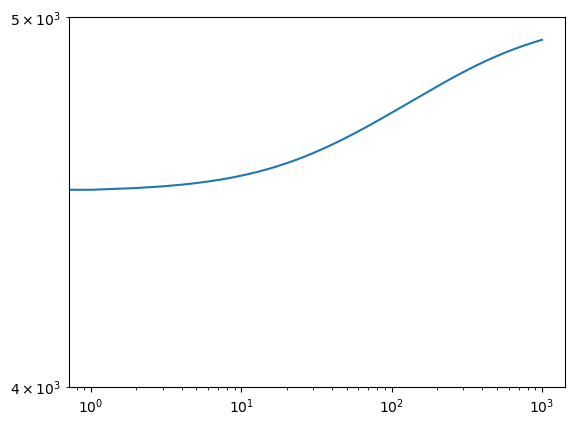

In [234]:
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(4e3,5e3)

In [235]:
0.1 / 3e-7

333333.3333333334

In [236]:
ndis_C = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vZ.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=20,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(1000.0, 10000.0)

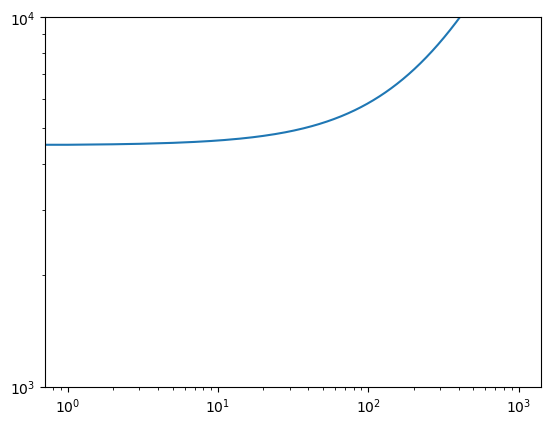

In [240]:
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(1e3,1e4)

In [246]:
ndis_C = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vZ0.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in = ndis_C[:,2:-2,2:-2]
ndis_C_log = np.log10(ndis_C_in + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0, 100, NX, endpoint = False)
y = np.linspace(0, 100, NX, endpoint = False)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(4000.0, 5000.0)

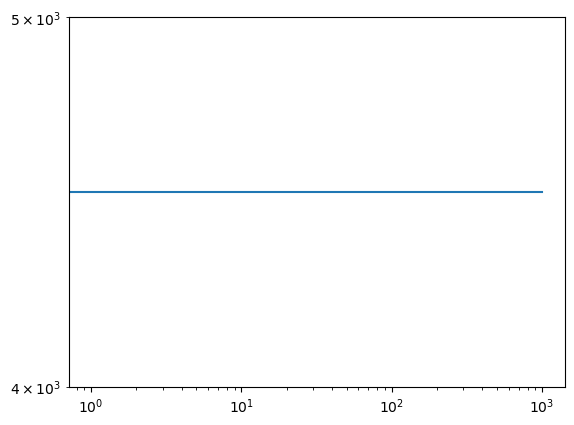

In [247]:
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(4e3,5e3)

In [248]:
N_tot

array([4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500., 4500.,
       4500., 4500.,

In [301]:
ndis_C_R = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vR0_ab.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in_R = ndis_C_R[:,2:-2,2:-2]
ndis_C_log_R = np.log10(ndis_C_in_R + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in_R[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in_R[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(400.0, 600.0)

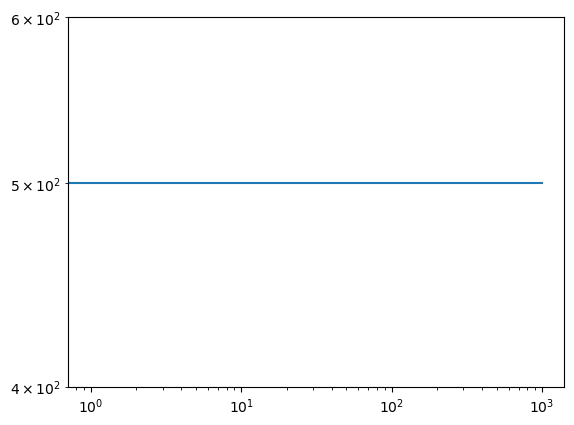

In [302]:
temp = np.sum(ndis_C_in_R * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(4e2,6e2)

In [303]:
ndis_C_Z = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vZ0_ab.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in_Z = ndis_C_Z[:,2:-2,2:-2]
ndis_C_log_Z = np.log10(ndis_C_in_Z + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in_Z[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in_Z[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(490, 510)

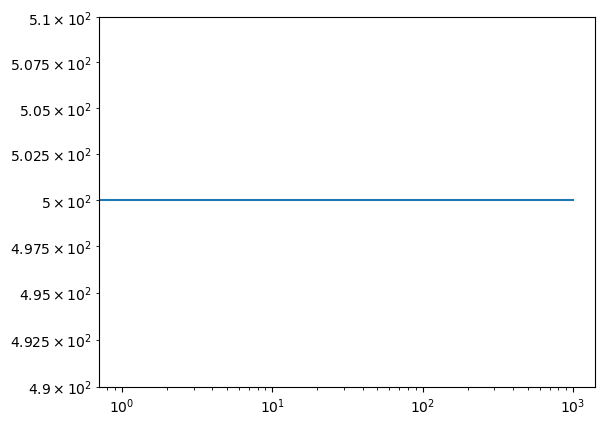

In [304]:
temp = np.sum(ndis_C_in_Z * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(490,510)

(4000.0, 6000.0)

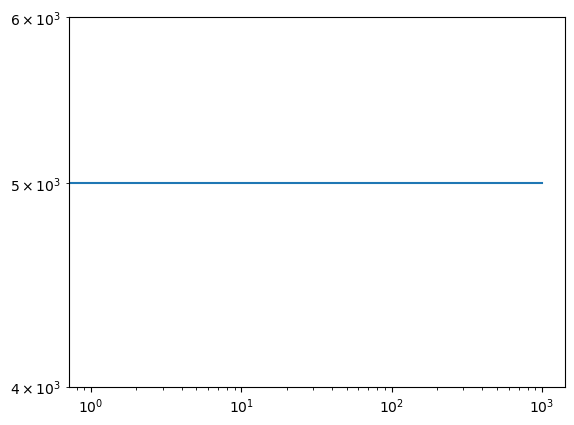

In [276]:
x = np.linspace(0.5, 99.5, NX)
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(4e3,6e3)

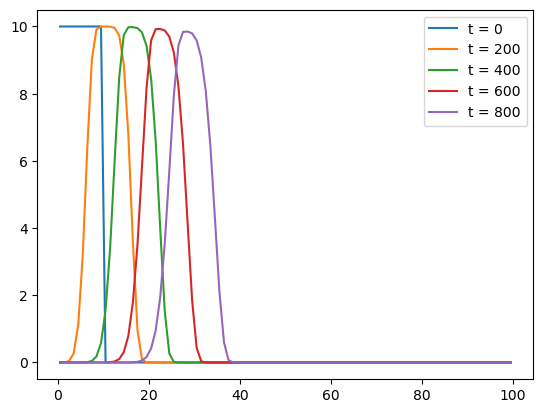

In [309]:
x = np.linspace(0.5, 99.5, NX)
for i in range(5):
    plt.plot(x, ndis_C_in_Z[i*200, 9], label = f"t = {i*200}")
plt.legend()

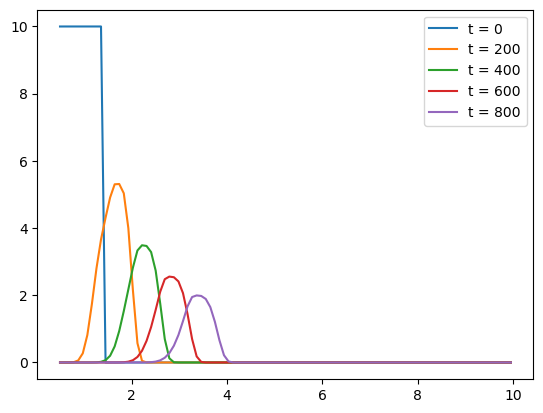

In [316]:
x = np.linspace(0.5, 9.95, NX)

for i in range(5):
    plt.plot(x, ndis_C_in_R[i*200, :, 9], label = f"t = {i*200}")
plt.legend()

(490, 510)

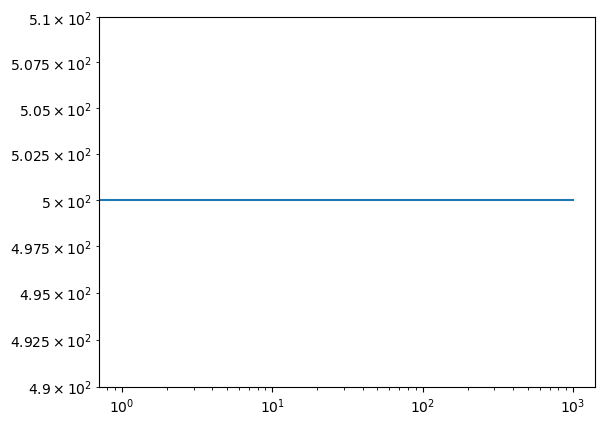

In [273]:
x = np.linspace(0.05, 9.95, NX)
temp = np.sum(ndis_C_in * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(490,510)

In [317]:
ndis_C_Z = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vZ0_rb.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in_Z = ndis_C_Z[:,2:-2,2:-2]
ndis_C_log_Z = np.log10(ndis_C_in_Z + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in_Z[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in_Z[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(490, 510)

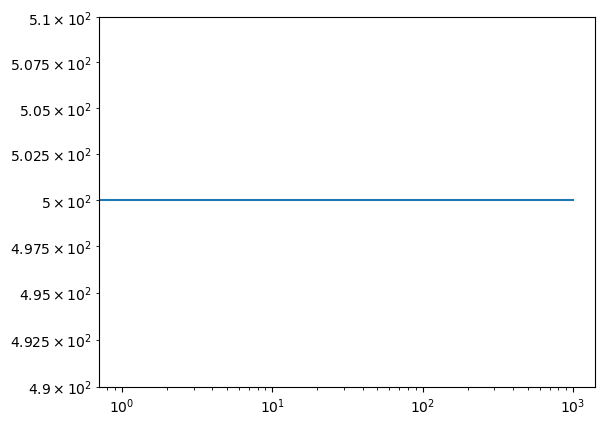

In [318]:
x = np.linspace(0.05, 9.95, NX)
temp = np.sum(ndis_C_in_Z * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(490,510)

In [319]:
ndis_C_R = np.fromfile("ndis_C_linear_t_delta_inj_dt10_vR0_rb.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in_R = ndis_C_R[:,2:-2,2:-2]
ndis_C_log_R = np.log10(ndis_C_in_R + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_in_R[0].T,shading="auto", vmin = 0.01, vmax = 1 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('linear scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_in_R[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

(490, 510)

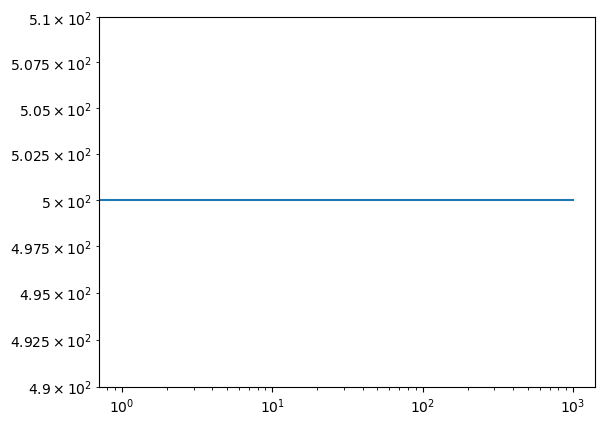

In [320]:
x = np.linspace(0.05, 9.95, NX)
temp = np.sum(ndis_C_in_R * x[None, :, None], axis = -1)
N_tot = np.sum(temp, axis = -1)
t = np.arange(1000)
plt.plot(t, N_tot)
plt.xscale("log")
plt.yscale("log")
plt.ylim(490,510)

In [328]:
ndis_C_R = np.fromfile("ndis_C_linear_t_const_inj_dt10_vR.bin",dtype = np.float64).reshape(1000,NX + 4, NX + 4)
ndis_C_in_R = ndis_C_R[:,2:-2,2:-2]
ndis_C_log_R = np.log10(ndis_C_in_R + 1e-100)

fig, ax = plt.subplots()

NX = 100

x = np.linspace(0.05, 9.95, NX)
y = np.linspace(0.05, 9.95, NX)

# 初始图
ndis = ax.pcolormesh(x, y, ndis_C_log_R[0].T,shading="auto", vmin = 0, vmax = 5 )

# 3. 添加 colorbar（直接绑定 ndis 对象）
cbar = fig.colorbar(ndis, ax=ax)
cbar.set_label('log scale')  # 可选：添加色条标签

def animate(i):
    ndis.set_array(ndis_C_log_R[i].T.ravel())
    return ndis,

ani = animation.FuncAnimation(
    fig,
    animate,
    frames=1000,
    interval=10,
    blit=False  
)

plt.close(fig)
HTML(ani.to_html5_video())

array([1.66656668e+05, 2.71551740e+05, 4.21866324e+05, 5.84577367e+05,
       7.50250235e+05, 9.16912706e+05, 1.08260226e+06, 1.25324323e+06,
       1.40417113e+06, 1.66666667e+06, 1.56927225e+06, 1.44746478e+06,
       1.33462589e+06, 1.23618516e+06, 1.15085470e+06, 1.07646184e+06,
       1.01109161e+06, 9.53208955e+05, 9.01599369e+05, 8.55296055e+05,
       8.13519976e+05, 7.75634139e+05, 7.41114011e+05, 7.09535817e+05,
       6.80570448e+05, 6.53947457e+05, 6.29351209e+05, 6.06260444e+05,
       5.83812594e+05, 5.60774267e+05, 5.35620699e+05, 5.06680776e+05,
       4.72318560e+05, 4.31115566e+05, 3.82001466e+05, 3.24360847e+05,
       2.58347163e+05, 1.85856385e+05, 1.12612875e+05, 5.04412005e+04,
       1.33033750e+04, 1.47674220e+03, 4.62842767e+01, 2.76430962e-01,
       2.23233617e-04, 1.82895001e-08, 5.35230957e-13, 3.67277902e-13,
       2.71921677e-13, 1.94829159e-13, 1.36739325e-13, 9.44517374e-14,
       6.42211973e-14, 4.29659138e-14, 2.82756273e-14, 1.82997353e-14,
      